# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [ ]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 무작위로 샘플 인덱스 선택
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 535kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.86MB/s]


In [ ]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


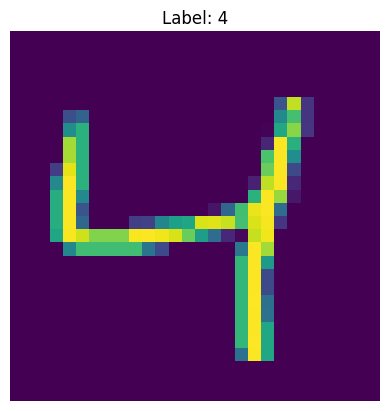

In [ ]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
image, label = train_subset[1]

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze()

# 이미지 출력
plt.imshow(image)  # 이미지 표시
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden lyaer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [ ]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

#### **ANN 모델 생성**

In [ ]:
# ANN Model
class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()

        # Linear function 1: input_dim --> hidden_dim  (입력 차원에서 숨겨진 계층으로)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = nn.ReLU()

        # Linear function 2:hidden_dim --> hidden_dim (숨겨진 계층을 한 번 더 통과)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수 사용)
        self.tanh2 = nn.Tanh()

        # Linear function 3: hidden_dim --> hidden_dim  (추가 숨겨진 계층)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = nn.ELU()

        # Linear function 4: hidden_dim --> output_dim  (마지막 출력층)
        self.fc4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2(out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3(out)

        # Linear function 4
        out =self.fc4(out) # 마지막 출력층
        return out

In [ ]:
# ANN 객체 생성
input_dim = 28*28  # 이미지 크기 (28x28)
hidden_dim = 150  # 하이퍼파라미터 (150으로 설정)
output_dim = 5  # 출력 클래스 개수 (0~4)


model = ANNModel(input_dim,hidden_dim,output_dim)
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss() # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

#### **ANN 모델 학습**

In [ ]:
# ANN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트

# 전체 학습
for epoch in range(10):

    # 배치 단위 학습
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1, 28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels  # 텐서 형태 유지

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train)

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0


            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:

                test = images.view(-1,28*28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                # Forward
                # 예측값 계산
                outputs = model(test)

                # 예측값 중 가장 높은 값을 선택
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))


Iteration: 500  Loss: 0.2597530782222748  Accuracy: 96.3416976928711 %
Iteration: 1000  Loss: 0.08259297907352448  Accuracy: 97.1978988647461 %
Iteration: 1500  Loss: 0.15206100046634674  Accuracy: 97.43140411376953 %
Iteration: 2000  Loss: 0.08849308639764786  Accuracy: 97.6259994506836 %
Iteration: 2500  Loss: 0.09652344137430191  Accuracy: 97.76220703125 %
Iteration: 3000  Loss: 0.12150998413562775  Accuracy: 97.95680236816406 %
Iteration: 3500  Loss: 0.11359759420156479  Accuracy: 98.17085266113281 %
Iteration: 4000  Loss: 0.08841145783662796  Accuracy: 98.1903076171875 %
Iteration: 4500  Loss: 0.058830466121435165  Accuracy: 98.50165557861328 %


#### **ANN 학습 결과**

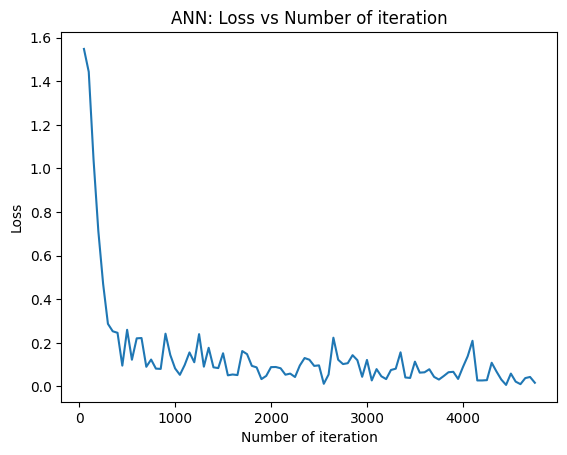

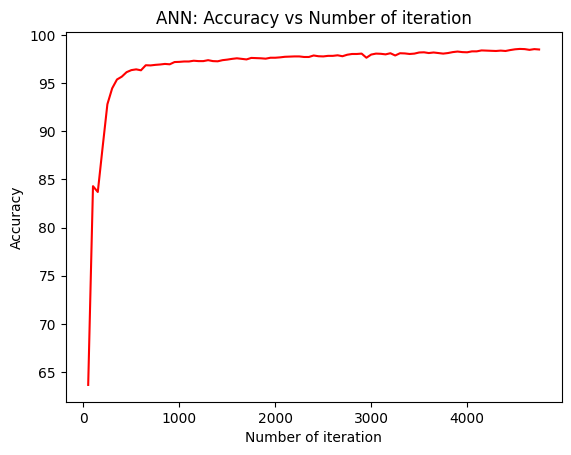

In [ ]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗



---
**[해석]**
- iteration 횟수가 증가할수록 정확도는 증가하고, Loss는 감소했다.


#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

In [ ]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습
import matplotlib.pyplot as plt

hidden_dims = [50, 100, 150, 200]

results = {}

for h_dim in hidden_dims:
    print(f"\n hidden_dim = {h_dim}")

    model = ANNModel(input_dim, h_dim, output_dim)
    loss_ftn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.02)

    loss_list = []
    acc_list = []

    for epoch in range(5):
        correct = 0
        total = 0

        for images, labels in train_loader:
            train = images.view(-1, 28*28)

            optimizer.zero_grad()
            outputs = model(train)
            loss = loss_ftn(outputs, labels)
            loss.backward()
            optimizer.step()

        # 평가
        for images, labels in test_loader:
            test = images.view(-1, 28*28)
            outputs = model(test)
            predicted = torch.max(outputs.data, 1)[1]

            total += len(labels)
            correct += (predicted == labels).sum()

        acc = 100 * correct / float(total)

        loss_list.append(loss.item())
        acc_list.append(acc)

    results[h_dim] = (loss_list, acc_list)


 hidden_dim = 50

 hidden_dim = 100

 hidden_dim = 150

 hidden_dim = 200


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


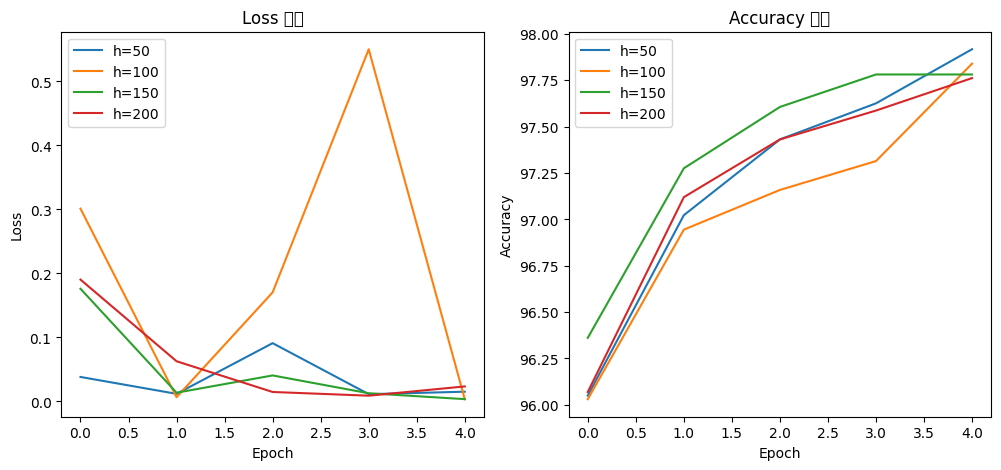

In [ ]:
# 실험 1 모델 학습 결과 시각화
plt.figure(figsize=(12,5))

# Loss 그래프
plt.subplot(1,2,1)
for h_dim in hidden_dims:
    plt.plot(results[h_dim][0], label=f'h={h_dim}')
plt.title("Loss 비교")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy 그래프
plt.subplot(1,2,2)
for h_dim in hidden_dims:
    plt.plot(results[h_dim][1], label=f'h={h_dim}')
plt.title("Accuracy 비교")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- 너무 작은 경우 모델이 단순해지고, 과소적합
- 적절한 경우 중요한 패턴을 충분히 학습해 일반화 성능이 좋음
- 너무 큰 경우 모델이 지나치게 복잡해져 과적합 문제 발생

In [ ]:
# 실험 2 learning_rates=[0.1-0.005 사이 값들] 로 학습
## 답안 ##
import torch
import torch.nn as nn

learning_rates = [0.1, 0.05, 0.02, 0.01, 0.005]  # 0.1 ~ 0.005 사이

lr_results = {}  # 결과 저장

for lr in learning_rates:
    print(f"learning_rate = {lr}")

    model = ANNModel(input_dim, 150, output_dim)  # hidden_dim은 150으로 고정
    loss_ftn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    loss_list = []
    acc_list = []

    for epoch in range(5):
        # -------- 학습 --------
        for images, labels in train_loader:
            train = images.view(-1, 28*28)

            optimizer.zero_grad()
            outputs = model(train)
            loss = loss_ftn(outputs, labels)
            loss.backward()
            optimizer.step()

        # -------- 평가 --------
        correct = 0
        total = 0
        for images, labels in test_loader:
            test = images.view(-1, 28*28)
            outputs = model(test)

            predicted = torch.max(outputs.data, 1)[1]
            total += len(labels)
            correct += (predicted == labels).sum()

        accuracy = 100 * correct / float(total)
        loss_list.append(loss.item())
        acc_list.append(accuracy)

    lr_results[lr] = (loss_list, acc_list)

learning_rate = 0.1
learning_rate = 0.05
learning_rate = 0.02
learning_rate = 0.01
learning_rate = 0.005


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


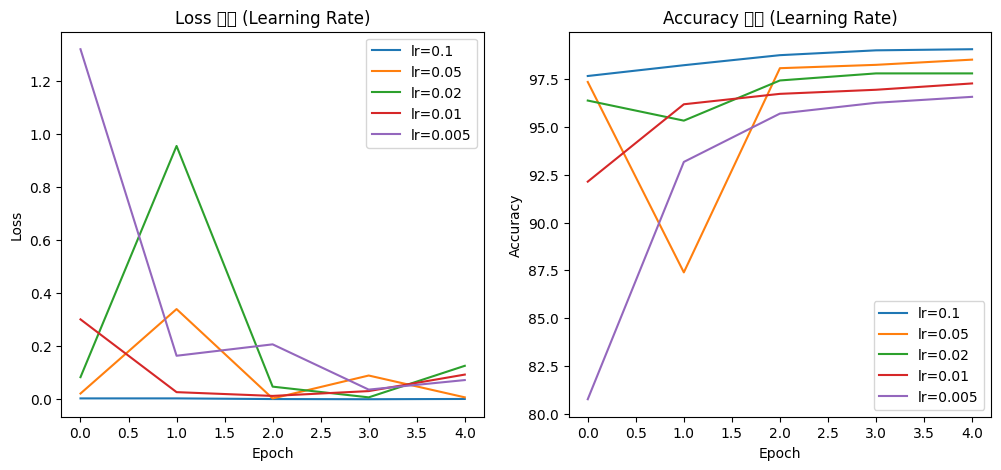

In [ ]:
# 실험 2 모델 학습 결과 시각화
## 답안 ##
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss 그래프
plt.subplot(1,2,1)
for lr in learning_rates:
    plt.plot(lr_results[lr][0], label=f'lr={lr}')
plt.title("Loss 비교 (Learning Rate)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy 그래프
plt.subplot(1,2,2)
for lr in learning_rates:
    plt.plot(lr_results[lr][1], label=f'lr={lr}')
plt.title("Accuracy 비교 (Learning Rate)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

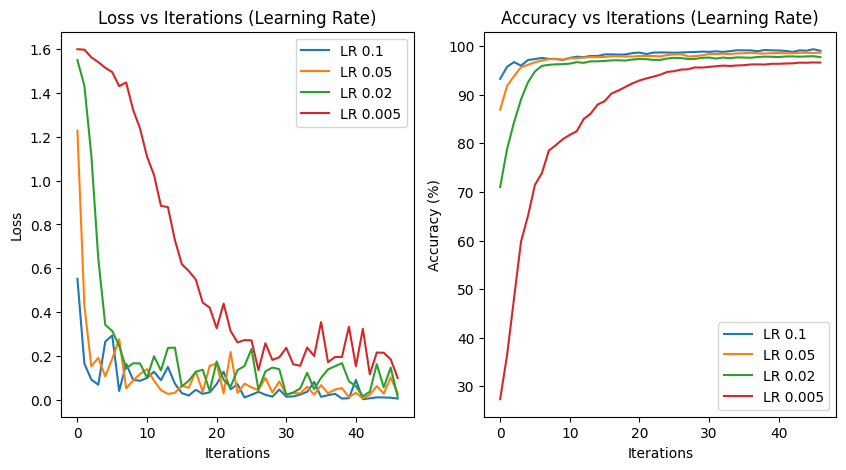

In [ ]:
# 실험 2 모델 학습 결과 시각화
## 답안 ##

**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
- learning rate가 너무 크면 한번에 너무 많이 이동해서 학습이 불안정해지고, 너무 작아지면 loss 감소가 느리고 학습 시간이 오래 걸린다.

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정

        # 합성곱 계층 2 (Conv Layer 2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) # kernel size를 2로 설정

        # Fully Connected Layer
        self.fc1 = nn.Linear(32*4*4, 10)  # 입력 차원 및 출력 차원 지정

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2
        out = self.maxpool2(out)

        # feature map을 flatten하게
        out = out.view(out.size(0), -1)

        # 완전 연결 계층
        out = self.fc1(out)

        return out


In [ ]:
# CNN 객체 생성
model = CNNModel()
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)  # 학습률을 자유롭게 설정해주세요

#### **CNN 모델 학습**

In [ ]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트
num_epochs = 20  # 학습할 에포크 수 설정 -> 자유롭게 설정해주셔도 됩니다

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels in train_loader:
        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # 손실 계산
        loss = loss_ftn(outputs, labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적
        running_loss += loss.item()
        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            correct = 0
            total = 0

            with torch.no_grad():  # 평가
                for images, labels in test_loader:
                    # 모델 예측 수행
                    outputs = model(images)

                    # 가장 확률이 높은 클래스 선택
                    predicted = torch.max(outputs.data, 1)[1]

                    # 총 샘플 수 및 올바른 예측 개수 누적
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 0.3373862797732704
Epoch 2, Loss: 0.10640516544211975
Epoch 3, Loss: 0.07842061504061064
Epoch 4, Loss: 0.061139111491921506
Epoch 5, Loss: 0.05114007938073827
Epoch 6, Loss: 0.04408124721869593
Epoch 7, Loss: 0.0396954455385704
Epoch 8, Loss: 0.035584847197094094
Epoch 9, Loss: 0.03241347783465825
Epoch 10, Loss: 0.02986148195555103
Epoch 11, Loss: 0.027860139107618965
Epoch 12, Loss: 0.02594936961436446
Epoch 13, Loss: 0.024543797207820288
Epoch 14, Loss: 0.02300087537816147
Epoch 15, Loss: 0.021760526905030726
Epoch 16, Loss: 0.020666972651644095
Epoch 17, Loss: 0.020219437819191048
Epoch 18, Loss: 0.018840339599590073
Epoch 19, Loss: 0.017954631465205137
Epoch 20, Loss: 0.01734890001769254


#### **CNN 학습 결과**

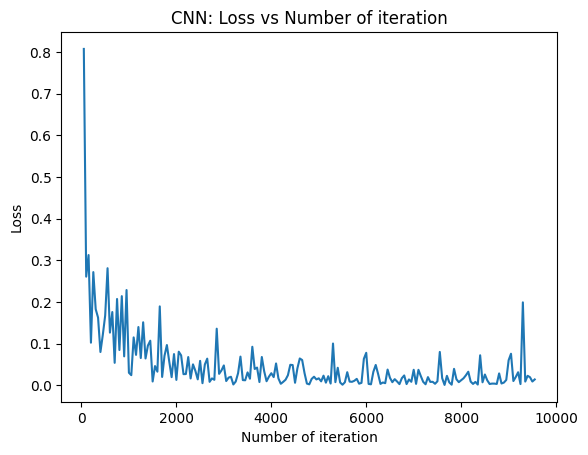

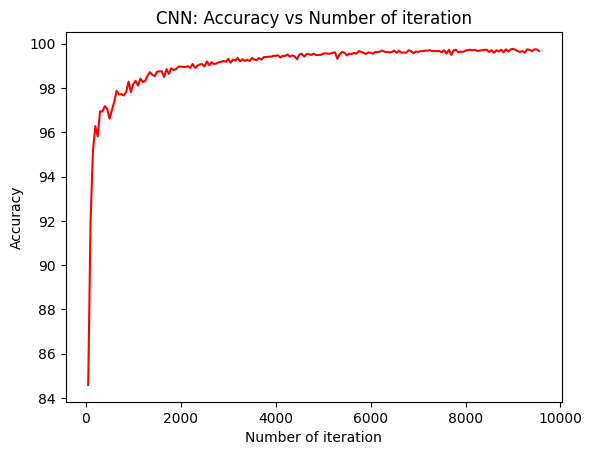

In [26]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗



---
**[답변]**
-MNIST 데이터셋에서 ANN과 CNN의 학습 결과를 비교하면, 두 모델의 성능 차이가 뚜렷하게 나타난다. ANN의 경우 loss가 초반에 급격히 감소한 뒤 점차 완만하게 줄어들며 수렴하지만, 학습 과정에서 일정 수준의 변동이 계속 발생한다. 이는 ANN이 이미지를 1차원 벡터로 변환하여 처리하기 때문에 픽셀 간의 공간적 관계를 충분히 반영하지 못하기 때문이다. 반면 CNN은 학습 초반부터 정확도가 빠르게 상승하여 약 99% 수준에 안정적으로 도달하며, 이후에도 큰 변동 없이 높은 성능을 유지한다. 이는 CNN이 합성곱 연산을 통해 이미지의 지역적 특징과 패턴을 효과적으로 추출하기 때문이다.

-ANN은 입력층, 은닉층, 출력층으로 구성된 가장 기본적인 신경망 구조로, 모든 노드가 서로 연결된 fully-connected 형태를 가진다. 구조가 단순하고 다양한 문제에 적용 가능하지만, 이미지처럼 구조적인 정보를 가지는 데이터에서는 성능이 제한적이다. 반면 CNN은 합성곱 층과 풀링 층을 활용하여 이미지의 공간적 특징을 보존하면서 학습하는 모델로, 엣지나 형태 같은 중요한 패턴을 자동으로 추출할 수 있다. 이러한 특성 때문에 CNN은 MNIST와 같은 이미지 분류 문제에서 ANN보다 훨씬 높은 정확도와 안정적인 학습 성능을 보인다.
